<a href="https://colab.research.google.com/github/madan-genai/Blog_Writing_Agent/blob/main/BWA_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install  langchain_groq langchain_core langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
!apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (8,186 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [3]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [40]:
import subprocess
import time

subprocess.Popen(["ollama", "serve"])
time.sleep(5)

!ollama pull qwen3:8b

In [25]:
import os
os.environ["TAVILY_API_KEY"]="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"

In [6]:
!pip install langchain-ollama

In [7]:
from __future__ import annotations
from typing import TypedDict, List , Annotated, Literal , Optional
from pydantic import BaseModel, Field
from langgraph.graph import START, END, StateGraph
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama
from langchain_community.tools.tavily_search import TavilySearchResults

/tmp/ipykernel_942/3551539995.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [41]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3:8b",
    temperature=0
)

In [42]:
response = llm.invoke("Explain RAG in simple terms")

print(response.content)

Sure! Let me explain **RAG** (Retrieval-Augmented Generation) in simple terms:

Imagine you're writing an essay and need to find some facts. Instead of just making things up, you look up the facts first (like checking a book or website) and then use those facts to write your essay. That’s basically what **RAG** does, but for AI models.

### How RAG Works:
1. **Retrieval**: The AI looks for relevant information from a database, document, or the internet. For example, if you ask, "What’s the capital of France?" it might pull up "Paris" from its data.
2. **Generation**: The AI then uses that retrieved information to create a clear, helpful answer. It might add context, explain things, or even summarize multiple sources.

### Why It’s Useful:
- **Accuracy**: By using real data, the AI can answer questions more reliably (like "Paris is the capital of France").
- **Complex Answers**: For tricky questions (e.g., "How does climate change affect the environment?"), RAG can pull multiple facts a

In [44]:
class Task(BaseModel):
  id : int
  title : str
  goal : str = Field(...,description="One sentence describing what the reader should be able to do/understand after this section.",)
  bullets : List[str] = Field(...,
                              min_length=3,
                              max_length=6,
                              description="3–6 concrete, non-overlapping subpoints to cover in this section.")
  target_words : int = Field(..., description="Target word count for this section (120–550).")
  tags : List[str] = Field(default_factory=list)
  requires_research : bool =False
  requires_citations : bool = False
  requires_codes : bool = False

In [45]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
  title:str
  url:str
  published_at : Optional[str] = None
  source : Optional[str] = None

class RouterDecision(BaseModel):
  needs_research : bool
  mode : Literal["closed_book","hybrid", "open_book"]
  queries : List[str] = Field(default_factory=list)

class Evidence(BaseModel):
  evidence : List[EvidenceItem] = Field(default_factory=list)


In [46]:
import operator
class State(TypedDict):
  topic : str
  mode : str
  needs_research : bool
  queries : List[str]
  evidence : List[EvidenceItem]
  plan : Optional[Plan]
  sections : Annotated[List[tuple[int, str]], operator.add]
  final:str


In [47]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

In [48]:
def router_node(state:State)-> dict:
  topic = state["topic"]
  decider = llm.with_structured_output(RouterDecision)
  decision = decider.invoke(
      [
          SystemMessage(content=ROUTER_SYSTEM),
          HumanMessage(content=f"Topic: {topic}")
      ]
  )

  return {
      "needs_research" : decision.needs_research,
      "mode" : decision.mode,
      "queries" : decision.queries
  }

def route_next(state:State)->dict:
  return "research" if state["needs_research"] else "orchestrator"

In [49]:
def tavily_search(query: str, max_results : int=5) ->List[dict]:
  """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
  """
  tool=TavilySearchResults(max_results=max_results)
  results = tool.invoke({"query":query})

  normalized: List[dict] = []
  for r in results or []:
    normalized.append(
        {
            "title" : r.get("title") or "",
            "url" : r.get("url") or "",
            "source": r.get("source") or "",
            "published_at":r.get("published_at") or r.get("published_date"),
            "snippet" : r.get("snippet") or r.get("content") or "",
        }
    )
  return normalized




RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state:State)->dict:
  queries =(state.get("queries" ,[]) or [])
  max_results = 6

  raw_results :List[dict] = []
  for q in queries:
    raw_results.extend(tavily_search(q, max_results))

  if not raw_results :
    return {"evidence":[]}

  extractor=llm.with_structured_output(Evidence)
  pack=extractor.invoke(
      [
          SystemMessage(content=RESEARCH_SYSTEM),
          HumanMessage(content=f"Results: {raw_results}"),

      ]
  )

  dedup = {}
  for e in pack.evidence:
    if e.url:
      dedup[e.url] = e
  return {"evidence": list(dedup.values())}

In [50]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  - Bullets: Should be concise, high-level points or sub-sections. Detailed explanations, examples, and evidence integration occur in the worker stage.
  3) target word count (120–550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator(state:State)->dict:
  planner = llm.with_structured_output(Plan)
  evidence = state.get("evidence",[])
  mode = state.get("mode","closed_book")

  plan = planner.invoke(
      [
          SystemMessage(content=ORCH_SYSTEM),
          HumanMessage(content=(
              f"Topic:{state["topic"]}\n",
              f"Mode:{mode} \n\n",
              f"Evidence (ONLY use for fresh claims; may be empty):\n"
              f"{[e.model_dump() for e in evidence[:16]]}"
          )),
      ]
  )
  return {"plan":plan}

In [51]:
def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [52]:
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

In [53]:
def worker_node(payload:dict)->dict:
  task = Task(**payload["task"])
  plan = Plan(**payload["plan"])
  evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
  topic = payload["topic"]
  mode = payload.get("mode", "closed_book")

  bullets_text = "\n- " + "\n- ".join(task.bullets)

  evidence_text = ""
  if evidence:
      evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

  section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_codes: {task.requires_codes}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

In [54]:
from pathlib import Path
def reducer_node(state: State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

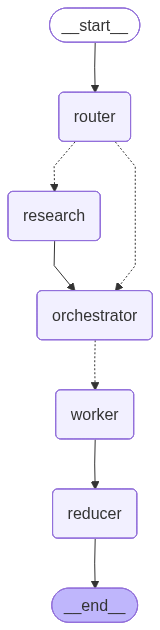

In [55]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [56]:
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [57]:
result = run("State of Multimodal LLMs in 2026")
print(result)

{'topic': 'State of Multimodal LLMs in 2026', 'mode': 'open_book', 'needs_research': True, 'queries': ['Latest advancements in multimodal LLMs in 2026 (specific models, architectures, and capabilities)', 'Top 5 multimodal LLMs released in 2026 with performance benchmarks', 'Industry applications of 2026 multimodal LLMs (e.g., healthcare, education, entertainment)', 'Challenges in training and deploying 2026 multimodal LLMs (data, compute, ethics)', '2026 trends in multimodal LLM integration with robotics and IoT devices', 'Comparative analysis of 2026 multimodal LLMs vs. 2023 models (accuracy, efficiency)', 'Regulatory developments impacting 2026 multimodal LLM deployment', 'Open-source vs. proprietary 2026 multimodal LLMs: adoption rates and ecosystems', '2026 breakthroughs in cross-modal reasoning (e.g., vision-language navigation)', 'Future outlook for multimodal LLMs beyond 2026 (research directions, risks)'], 'evidence': [EvidenceItem(title='Multimodal Large Language Models: A Sur

In [58]:
result

{'topic': 'State of Multimodal LLMs in 2026',
 'mode': 'open_book',
 'needs_research': True,
 'queries': ['Latest advancements in multimodal LLMs in 2026 (specific models, architectures, and capabilities)',
  'Top 5 multimodal LLMs released in 2026 with performance benchmarks',
  'Industry applications of 2026 multimodal LLMs (e.g., healthcare, education, entertainment)',
  'Challenges in training and deploying 2026 multimodal LLMs (data, compute, ethics)',
  '2026 trends in multimodal LLM integration with robotics and IoT devices',
  'Comparative analysis of 2026 multimodal LLMs vs. 2023 models (accuracy, efficiency)',
  'Regulatory developments impacting 2026 multimodal LLM deployment',
  'Open-source vs. proprietary 2026 multimodal LLMs: adoption rates and ecosystems',
  '2026 breakthroughs in cross-modal reasoning (e.g., vision-language navigation)',
  'Future outlook for multimodal LLMs beyond 2026 (research directions, risks)'],
 'evidence': [EvidenceItem(title='Multimodal Large 